# 11)
We can simulate the geometric distribution using bernoulli trials. Let $U \sim Unif(0,1)$ and $p$ be the probability of success. Then we can simulate the geometric distribution by letting $q = 1-p$ and checking how many trials it takes to get the first success.

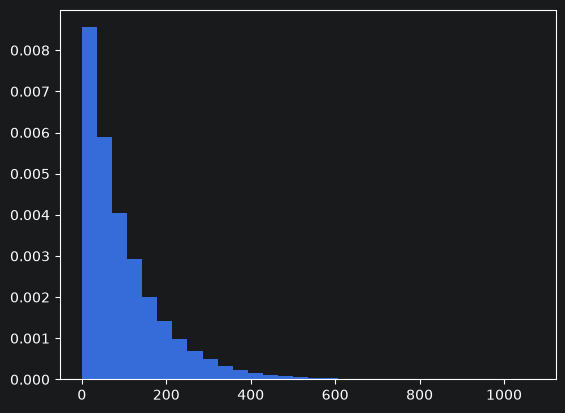

In [27]:
import numpy as np
import matplotlib.pyplot as plt

N = 10**5
p = 0.01
q = 1 - p
y = np.zeros(N)
for i in range(N):
    # For each instance
    loop = True
    k = 0
    while loop:
        # Count trials until we hit a success
        k += 1
        u = np.random.uniform(0, 1)
        if u > q:
            y[i] = k
            loop = False
plt.hist(y, density=True, bins = 30)
plt.show()

Following example 2.5, we can simulate the geometric(p) distribution by letting $q = 1-p$ and $U \sim Unif(0,1)$ then

$$ Y = \lfloor log(U)/log(q)\rfloor + 1 \sim Geom(p) $$

Now following example 2.1 we have that
$$
\dfrac{-1}{\lambda} log(U) = log(U^{-1/\lambda})  \sim exp(\lambda) = X
$$
Then
$$
\dfrac{-\lambda}{log(q)} X \sim \dfrac{log(U)}{log(q)}
$$
so
$$
Y = \lfloor log(U)/log(q)\rfloor + 1  = \lfloor -\lambda X/log(q) \rfloor + 1  \sim Geom(p)
$$

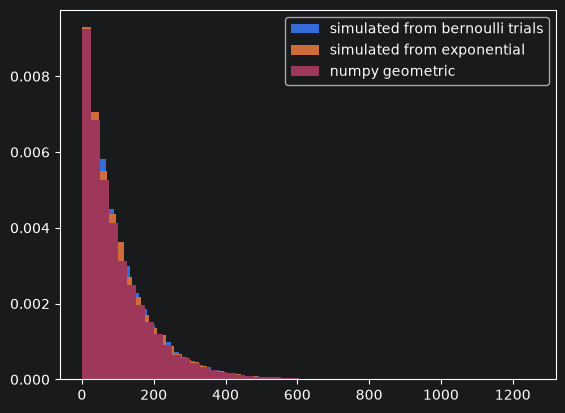

In [26]:
llambda = 1
u = np.random.uniform(0, 1, N)
x = -np.log(u)/llambda
y_exp = np.floor(-llambda*x/np.log(q)) + 1
plt.hist(y, density=True, bins = 50, label = "simulated from bernoulli trials")
plt.hist(y_exp, density=True, bins = 50, label = "simulated from exponential")

z = np.random.geometric(p, N)
plt.hist(z, density=True, bins = 50, label = "numpy geometric")
plt.legend()
plt.show()

We can see that we achive similar results, however it is much slower to simulate from bernoulli trials than from the exponential distribution. This is becuase our loop needs to run $100000 * 1/p = 100000 * 100 = 10^7$ times, while the exponential distribution only needs to run $10^5$ times.